In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Define CNN Architecture
class CNN(nn.Module):
    def __init__(self, kernel_size):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=kernel_size, padding=kernel_size // 2)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=kernel_size // 2)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Train and evaluate function
def train_and_evaluate(model, optimizer, epochs):
    criterion = nn.CrossEntropyLoss()
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, verbose=True)
    early_stopping_patience = 5
    best_loss = float('inf')
    no_improvement = 0

    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        test_accuracy = accuracy_score(all_labels, all_preds)
        test_accuracies.append(test_accuracy)

        scheduler.step(train_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Test Accuracy: {test_accuracy:.4f}")

        if train_loss < best_loss:
            best_loss = train_loss
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    return train_losses, test_accuracies

# Experiment with different hyperparameters
def experiment(kernel_size, optimizer_type, epochs):
    model = CNN(kernel_size=kernel_size).to(device)
    optimizer = optimizer_type(model.parameters(), lr=0.001)
    return train_and_evaluate(model, optimizer, epochs)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Run experiments
results = {}
kernel_sizes = [3, 5, 7]
optimizers = {'SGD': optim.SGD, 'RMSProp': optim.RMSprop, 'Adam': optim.Adam}
epochs_list = [5, 50, 100]

for kernel_size in kernel_sizes:
    for opt_name, opt_type in optimizers.items():
        for epochs in epochs_list:
            print(f"Running experiment with Kernel Size: {kernel_size}, Optimizer: {opt_name}, Epochs: {epochs}")
            results[(kernel_size, opt_name, epochs)] = experiment(kernel_size, opt_type, epochs)




100%|██████████| 170M/170M [01:02<00:00, 2.71MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Running experiment with Kernel Size: 3, Optimizer: SGD, Epochs: 5


c:\Users\LENOVO\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/5 - Train Loss: 2.2958 - Test Accuracy: 0.1746
Epoch 2/5 - Train Loss: 2.2766 - Test Accuracy: 0.2404
Epoch 3/5 - Train Loss: 2.2390 - Test Accuracy: 0.2557
Epoch 4/5 - Train Loss: 2.1722 - Test Accuracy: 0.2651
Epoch 5/5 - Train Loss: 2.0939 - Test Accuracy: 0.2763
Running experiment with Kernel Size: 3, Optimizer: SGD, Epochs: 50


c:\Users\LENOVO\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


...

Epoch 1/5 - Train Loss: 1.4113 - Test Accuracy: 0.5699
Epoch 2/5 - Train Loss: 1.0204 - Test Accuracy: 0.6575
Epoch 3/5 - Train Loss: 0.8294 - Test Accuracy: 0.6901
Epoch 4/5 - Train Loss: 0.6843 - Test Accuracy: 0.7005
Epoch 5/5 - Train Loss: 0.5578 - Test Accuracy: 0.7113
Running experiment with Kernel Size: 7, Optimizer: Adam, Epochs: 50


c:\Users\LENOVO\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50 - Train Loss: 1.3768 - Test Accuracy: 0.6019
Epoch 2/50 - Train Loss: 0.9813 - Test Accuracy: 0.6608
Epoch 3/50 - Train Loss: 0.7852 - Test Accuracy: 0.6987
Epoch 4/50 - Train Loss: 0.6295 - Test Accuracy: 0.7168
Epoch 5/50 - Train Loss: 0.4926 - Test Accuracy: 0.7249
Epoch 6/50 - Train Loss: 0.3696 - Test Accuracy: 0.7000
Epoch 7/50 - Train Loss: 0.2653 - Test Accuracy: 0.7158
Epoch 8/50 - Train Loss: 0.1867 - Test Accuracy: 0.7163
Epoch 9/50 - Train Loss: 0.1540 - Test Accuracy: 0.7206
Epoch 10/50 - Train Loss: 0.1162 - Test Accuracy: 0.7129
Epoch 11/50 - Train Loss: 0.1074 - Test Accuracy: 0.7073
Epoch 12/50 - Train Loss: 0.0976 - Test Accuracy: 0.7095
Epoch 13/50 - Train Loss: 0.0890 - Test Accuracy: 0.7075
Epoch 14/50 - Train Loss: 0.0896 - Test Accuracy: 0.6997
Epoch 15/50 - Train Loss: 0.0731 - Test Accuracy: 0.7099
Epoch 16/50 - Train Loss: 0.0756 - Test Accuracy: 0.7029
Epoch 17/50 - Train Loss: 0.0753 - Test Accuracy: 0.7075
Epoch 18/50 - Train Loss: 0.0646 - Test 

c:\Users\LENOVO\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100 - Train Loss: 1.3951 - Test Accuracy: 0.5961
Epoch 2/100 - Train Loss: 0.9932 - Test Accuracy: 0.6723
Epoch 3/100 - Train Loss: 0.7910 - Test Accuracy: 0.7038
Epoch 4/100 - Train Loss: 0.6357 - Test Accuracy: 0.7177
Epoch 5/100 - Train Loss: 0.4931 - Test Accuracy: 0.7199
Epoch 6/100 - Train Loss: 0.3631 - Test Accuracy: 0.7177
Epoch 7/100 - Train Loss: 0.2515 - Test Accuracy: 0.7129
Epoch 8/100 - Train Loss: 0.1731 - Test Accuracy: 0.7139
Epoch 9/100 - Train Loss: 0.1320 - Test Accuracy: 0.7100
Epoch 10/100 - Train Loss: 0.1134 - Test Accuracy: 0.7186
Epoch 11/100 - Train Loss: 0.1053 - Test Accuracy: 0.7237
Epoch 12/100 - Train Loss: 0.0845 - Test Accuracy: 0.7094
Epoch 13/100 - Train Loss: 0.0817 - Test Accuracy: 0.7016
Epoch 14/100 - Train Loss: 0.0790 - Test Accuracy: 0.7133
Epoch 15/100 - Train Loss: 0.0746 - Test Accuracy: 0.7139
Epoch 16/100 - Train Loss: 0.0723 - Test Accuracy: 0.6915
Epoch 17/100 - Train Loss: 0.0739 - Test Accuracy: 0.7088
Epoch 18/100 - Train Lo

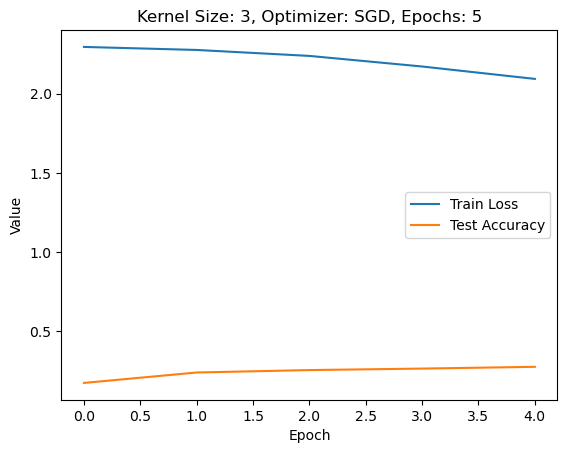

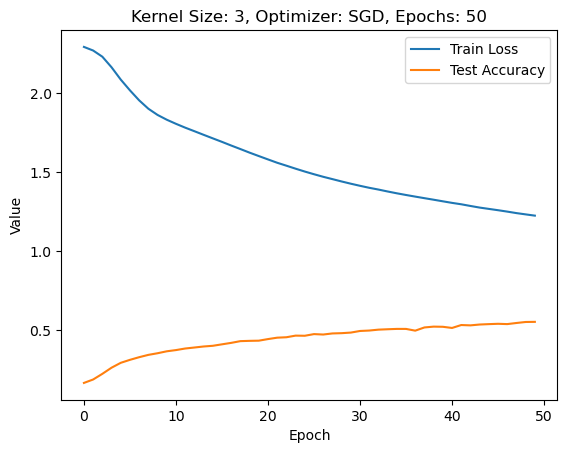

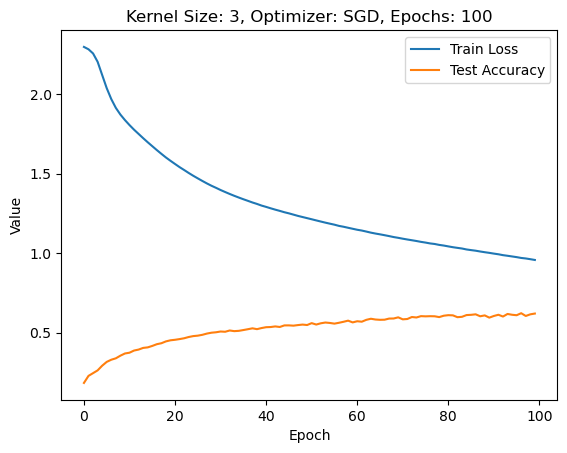

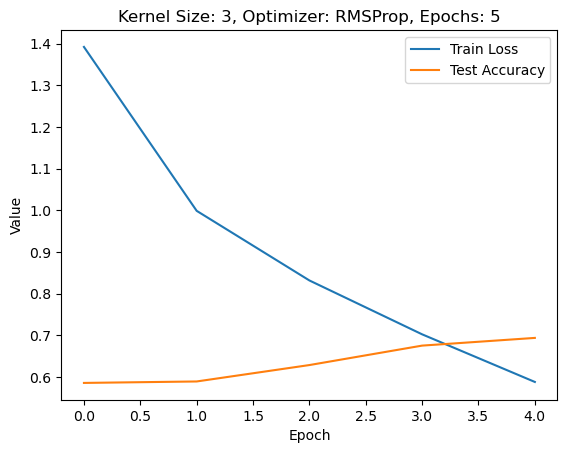

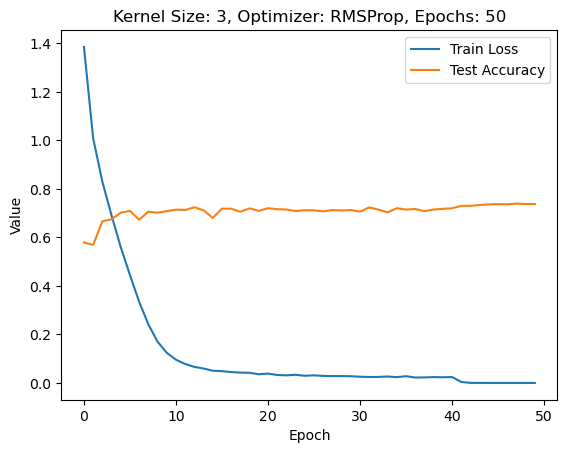

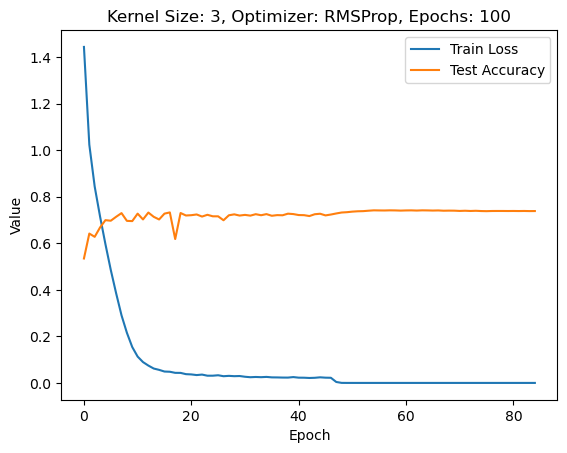

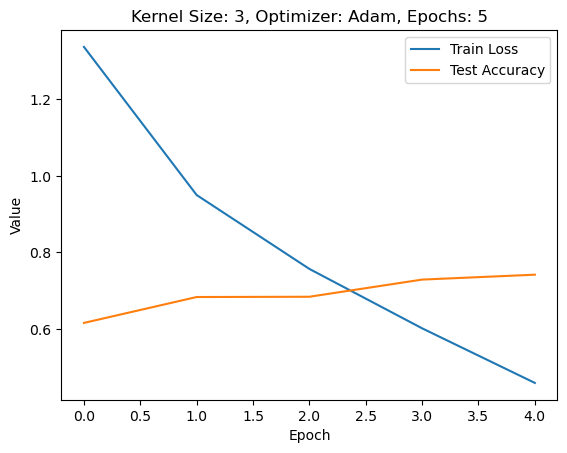

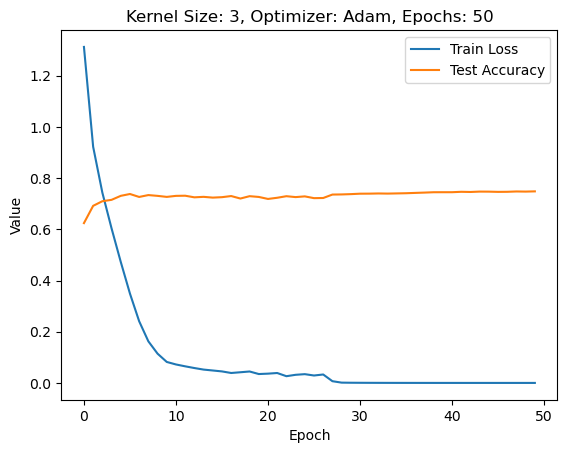

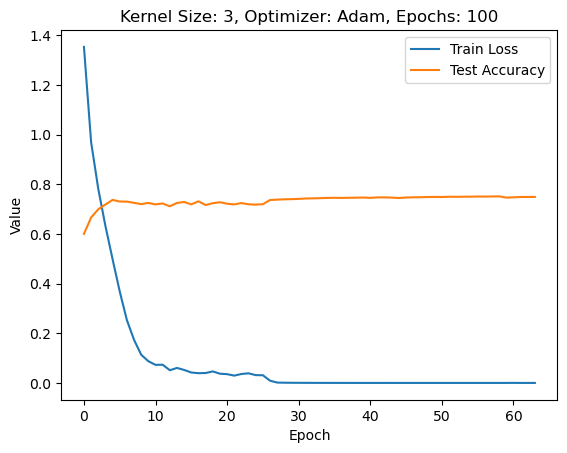

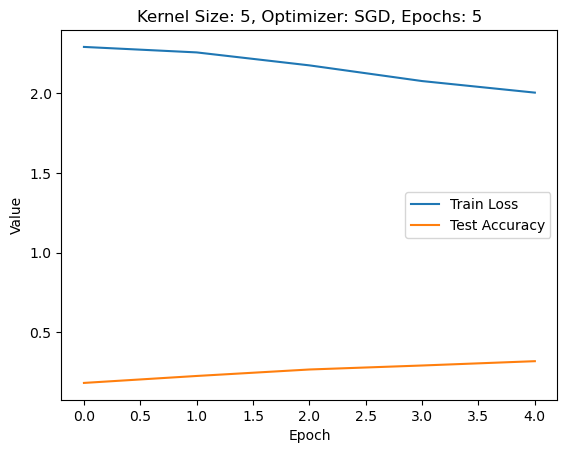

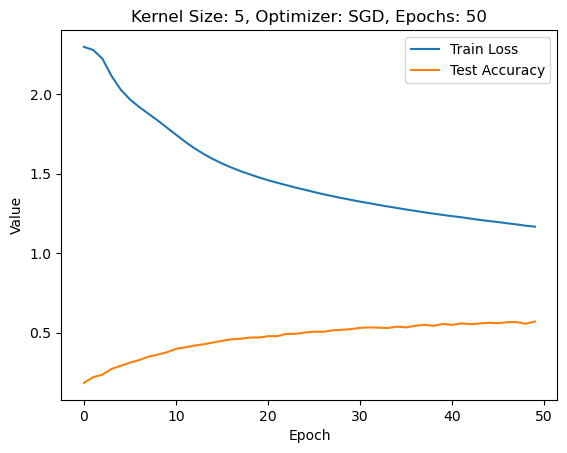

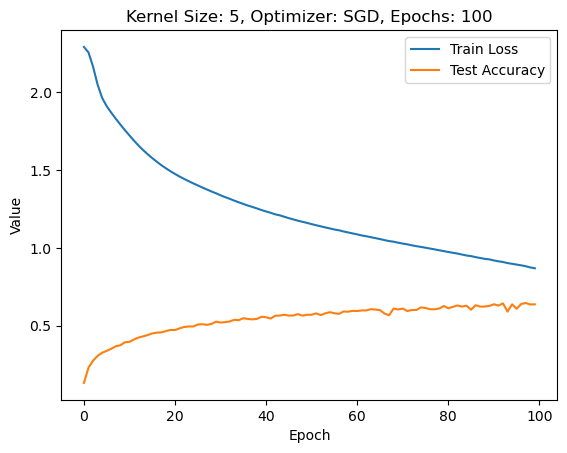

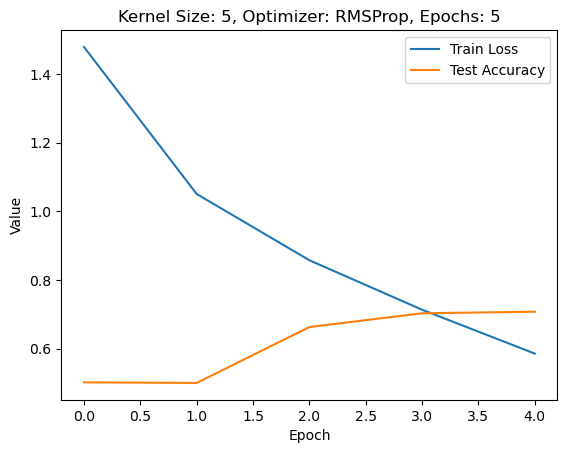

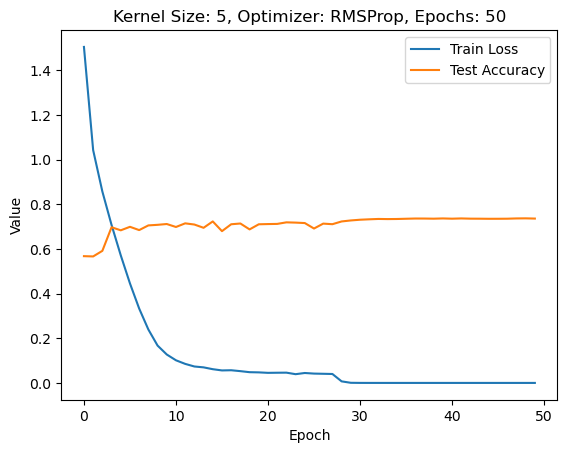

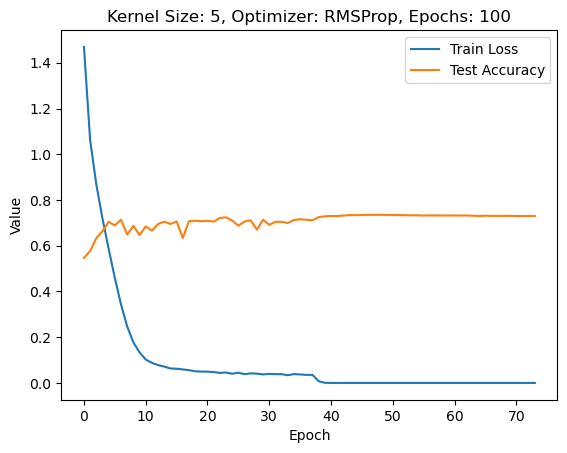

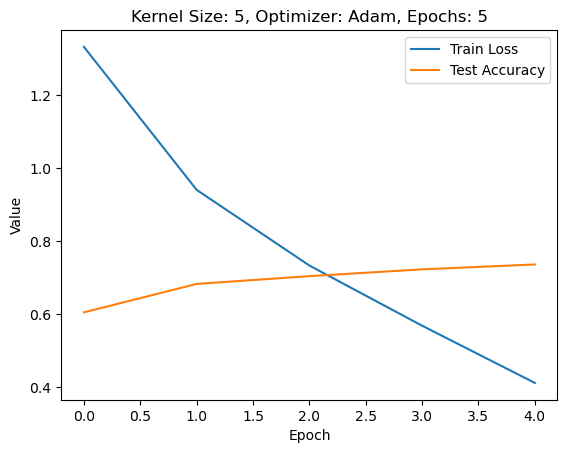

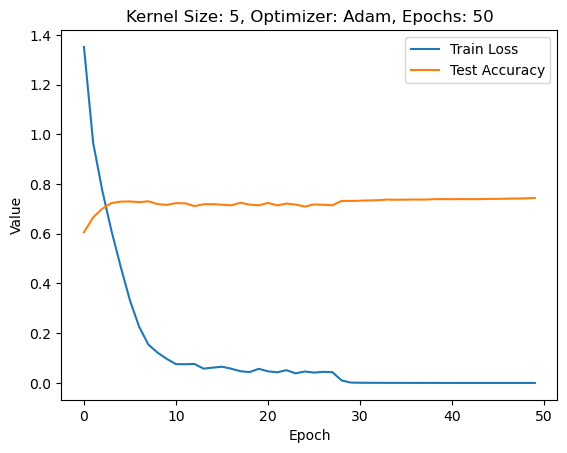

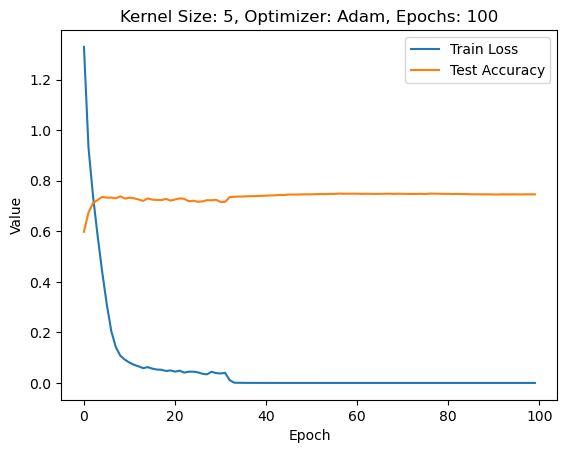

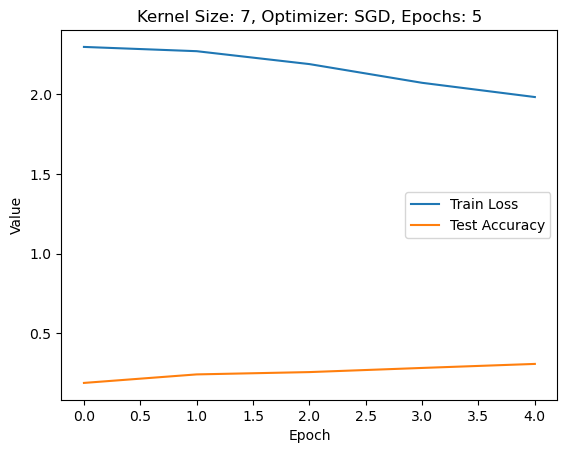

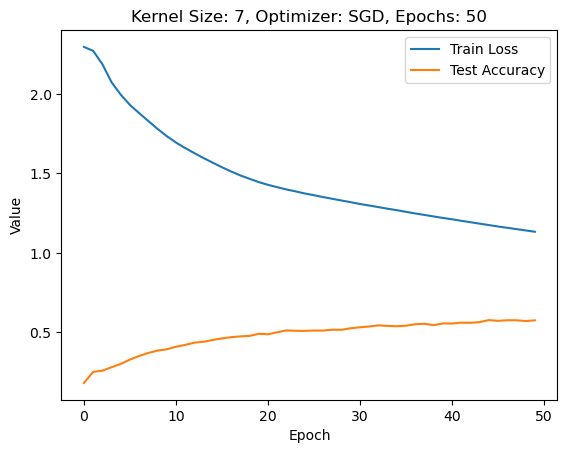

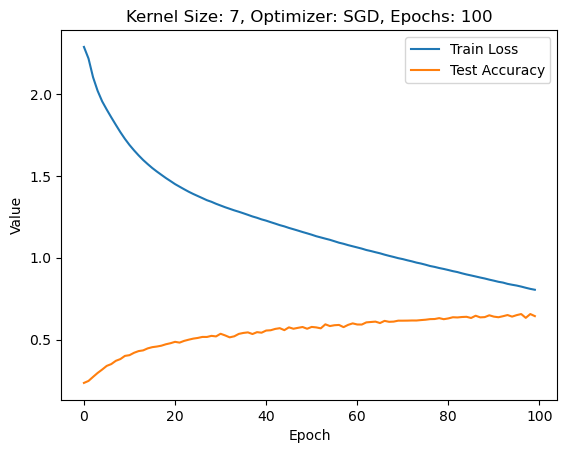

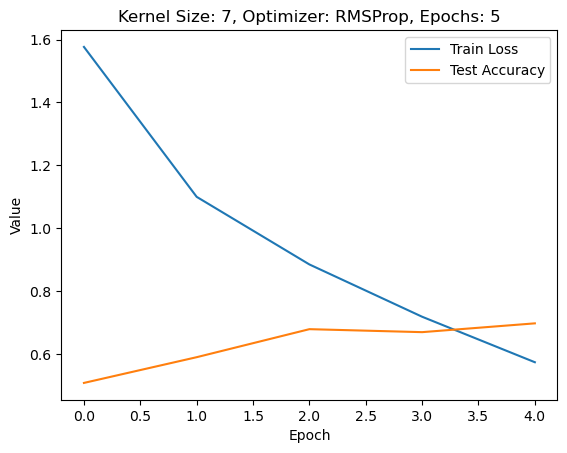

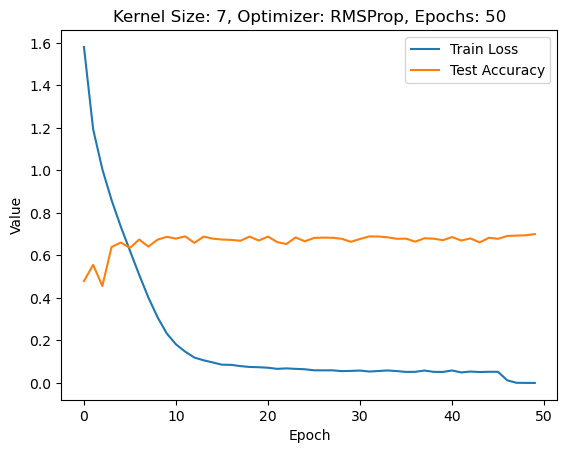

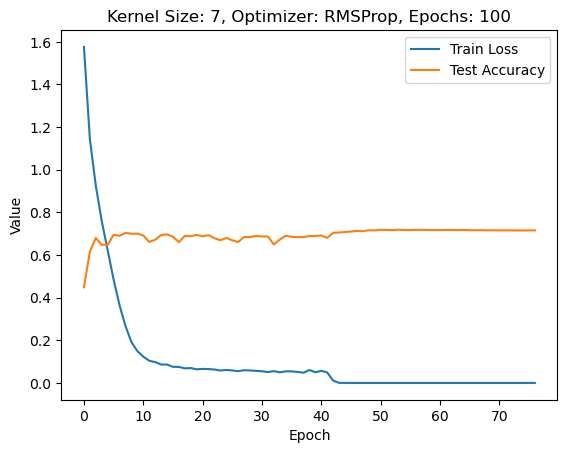

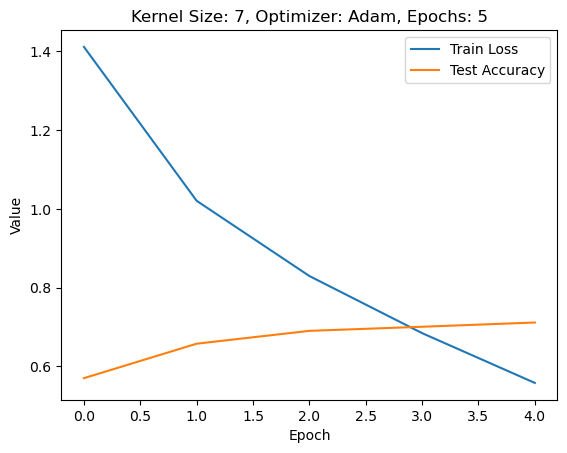

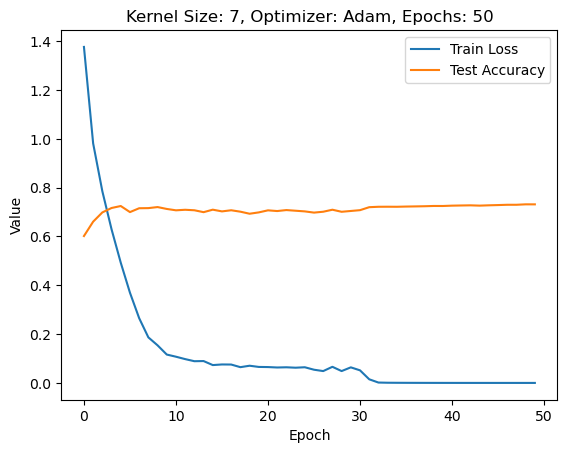

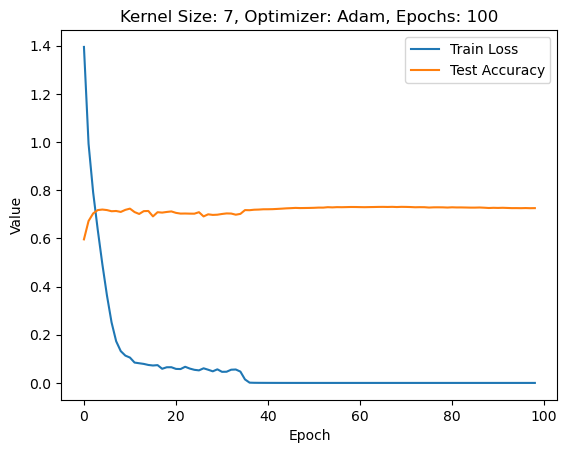

Top 5 Hyperparameter Configurations:
Config: (3, 'Adam', 100) - Max Test Accuracy: 0.7517
Config: (5, 'Adam', 100) - Max Test Accuracy: 0.7490
Config: (3, 'Adam', 50) - Max Test Accuracy: 0.7482
Config: (5, 'Adam', 50) - Max Test Accuracy: 0.7441
Config: (3, 'RMSProp', 100) - Max Test Accuracy: 0.7416


In [2]:
# Visualization
for (kernel_size, opt_name, epochs), (train_losses, test_accuracies) in results.items():
    plt.figure()
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_accuracies, label='Test Accuracy')
    plt.title(f"Kernel Size: {kernel_size}, Optimizer: {opt_name}, Epochs: {epochs}")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

# Output analysis results
# Select top 5 hyperparameters based on test accuracy
sorted_results = sorted(results.items(), key=lambda x: max(x[1][1]), reverse=True)[:5]
print("Top 5 Hyperparameter Configurations:")
for config, (train_losses, test_accuracies) in sorted_results:
    print(f"Config: {config} - Max Test Accuracy: {max(test_accuracies):.4f}")